In [65]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import root_mean_squared_error
import ast
import numpy as np
import pandas as pd
from shapely.geometry import box

In [11]:
path_map = 'World_Continents/World_Continents.shp'

In [12]:
Map = gpd.read_file(path_map)

In [13]:
Map = Map.to_crs(epsg=4326)

# Plot selected areas

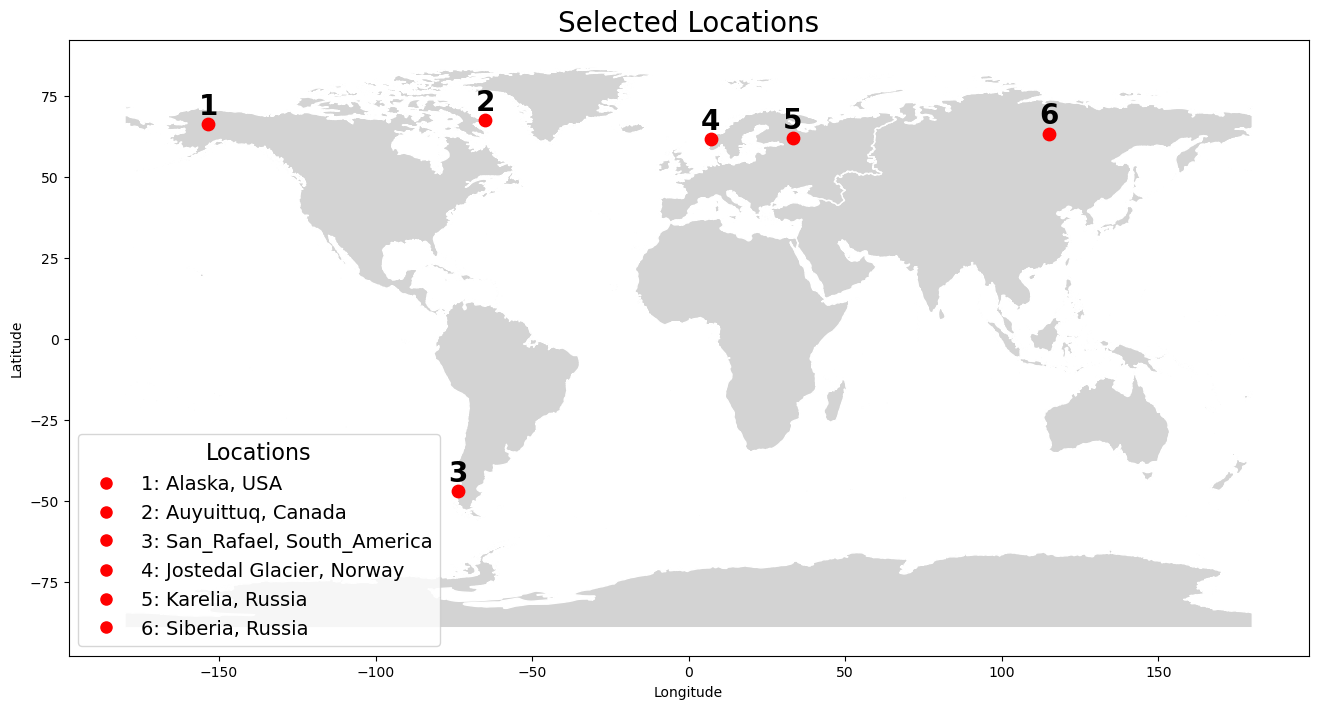

In [29]:
import geopandas as gpd
import matplotlib.pyplot as pyplot
from matplotlib.lines import Line2D

# Convert map to EPSG:4326
Map = Map.to_crs(epsg=4326)

# Create rectangular figure
fig, ax = pyplot.subplots(figsize=(16, 8))

# Plot base map
Map.plot(ax=ax, color="lightgrey", edgecolor="white")

# Locations: latitude, longitude
locations = {
    "Alaska, USA": [66.16, -153.37],
    "Auyuittuq, Canada": [67.50, -65.00],
    "San_Rafael, South_America": [-46.76, -73.55],
    "Jostedal Glacier, Norway": [61.68, 7.03],
    "Karelia, Russia": [61.82, 33.24],
    "Siberia, Russia": [63.32, 115.21],
}

legend_handles = []

# Add points and labels
for number, (name, coords) in enumerate(locations.items(), start=1):

    lat, lon = coords

    # Plot red point
    ax.scatter(
        lon,
        lat,
        color="red",
        s=80,              # Marker size
        zorder=5
    )

    # Add number above the point
    ax.text(
        lon,
        lat + 3.0,         # Vertical offset (degrees)
        str(number),
        fontsize=20,
        color="black",
        ha="center",
        fontweight="bold",
        zorder=6
    )

    # Legend entry
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='red',
            markeredgecolor='red',
            markersize=8,
            linestyle='None',
            label=f"{number}: {name}"
        )
    )

# Add legend
ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=14,
    title="Locations",
    title_fontsize=16
)

# Rectangular appearance
ax.set_aspect("auto")

# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
pyplot.title(
    "Selected Locations",
    fontsize=20
)

# Save figure
pyplot.savefig(
    "plots/Map_with_selected_locations.png",
    dpi=300,
    bbox_inches="tight"
)

pyplot.show()

# Collect all data in a dictionary

In [73]:
folder = Path("csv/testi")

lac = pd.DataFrame()
gac = pd.DataFrame()

for file in folder.rglob("*.csv"):
    df = pd.read_csv(file)
    lac = pd.concat([lac, df[df["datatype"] == "lac"]])
    gac = pd.concat([gac, df[df["datatype"] == "gac"]])

all_regions = set(lac["region"]).union(gac["region"])

regions = {
    region: {
        "lac": lac[lac["region"] == region],
        "gac": gac[gac["region"] == region]
    }
    for region in all_regions
}

print(lac.head())
print(gac.head())

# Example: access one region
print(regions["San_Rafael_South_America"]["lac"])
print(regions["San_Rafael_South_America"]["gac"])

       date datatype satellite            region  \
0  19960101      lac    noaa14        Alaska_USA   
2  19960102      lac    noaa14        Alaska_USA   
4  19960103      lac    noaa14        Alaska_USA   
0  19960101      lac    noaa14  Auyuittuq_Canada   
2  19960102      lac    noaa14  Auyuittuq_Canada   

                                                data  
0  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...  
2  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...  
4  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...  
0  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...  
2  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...  
       date datatype satellite            region   data
1  19960101      gac    noaa14        Alaska_USA  [nan]
3  19960102      gac    noaa14        Alaska_USA  [nan]
5  19960103      gac    noaa14        Alaska_USA  [nan]
1  19960101      gac    noaa14  Auyuittuq_Canada  [nan]
3  19960102      gac    noaa14  Auyuittuq_Canada  [nan]
       date datatype 

In [74]:
print(list(regions.keys()))

['Alaska_USA', 'San_Rafael_South_America', 'Siberia_Russia', 'Karelia_Russia', 'Auyuittuq_Canada', 'Jostedal_Glacier_Norway']


In [79]:
import numpy as np

region_values = {}

for region, data in regions.items():
    lac_values = data["lac"]["data"].tolist()
    gac_values = data["gac"]["data"].tolist()

    region_values[region] = {
        "lac": lac_values,
        "gac": gac_values
    }

# Example
print(region_values["Jostedal_Glacier_Norway"]["lac"])
print(region_values["Jostedal_Glacier_Norway"]["gac"])

['[nan, 81.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 82.0, nan]', '[nan, nan, nan, nan, nan, nan, nan, 41.0, nan, nan, nan, nan, nan, nan, nan, nan]', '[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]', '[nan, 81.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 82.0, nan]', '[nan, nan, nan, nan, nan, nan, nan, 41.0, nan, nan, nan, nan, nan, nan, nan, nan]', '[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]']
['[100.0]', '[100.0]', '[100.0]', '[100.0]', '[100.0]', '[100.0]']


In [83]:
lac_values = region_values["Jostedal_Glacier_Norway"]["lac"]

In [66]:
lac_values = ['[nan, nan, 51.0, nan, nan, nan, nan, nan, nan, 26, nan, nan, nan, 75, nan, nan]', '[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]', '[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]']

In [84]:
gac_values = region_values["Jostedal_Glacier_Norway"]["gac"]

In [67]:
gac_values = ['[0.0]', '[nan]', '[nan]']

In [90]:
import numpy as np
from sklearn.metrics import root_mean_squared_error

lac_values = [
    eval(x, {"nan": np.nan}) if isinstance(x, str) else x
    for x in lac_values
]

gac_values = [
    eval(x, {"nan": np.nan}) if isinstance(x, str) else x
    for x in gac_values
]

rmse_values = []

for lac, gac in zip(lac_values, gac_values):
    lac = np.array(lac, dtype=float)
    gac = np.array(gac, dtype=float)[0]

    # keep only valid LAC values
    lac = lac[~np.isnan(lac)]

    if len(lac) > 0 and not np.isnan(gac):
        rmse = root_mean_squared_error(
            np.full(len(lac), gac),
            lac
        )
    else:
        rmse = np.nan

    rmse_values.append(rmse)

print(rmse_values)
mean = np.mean(rmse_values)
print(mean)

(18.506755523321747 + 59.0 + 18.506755523321747 + 59.0)/4

[18.506755523321747, 59.0, nan, 18.506755523321747, 59.0, nan]
nan


38.75337776166087

In [ ]:
38.753378 

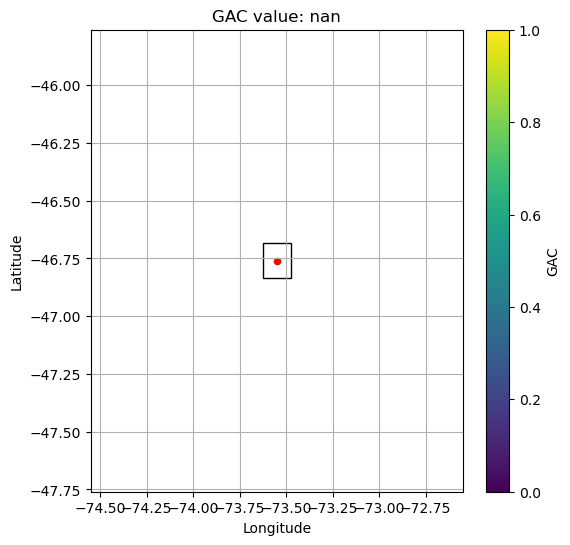

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Area centers: latitude, longitude
areas = {
    'Alaska_USA': [66.16, -153.37],
    'Auyuittuq_Canada': [67.5, -65],
    'San_Rafael_South_America': [-46.76, -73.55],
    'Jostedal_Glacier_Norway': [61.68, 7.03],
    'Karelia_Russia': [61.82, 33.24],
    'Siberia_Russia': [63.32, 115.21],
}

area = "San_Rafael_South_America"

# Select GAC
gac_area = gac[gac["region"] == area]

# Get the first value
value = gac_area.iloc[0]["data"][0]

lat, lon = areas[area]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the 0.15 x 0.15 degree footprint
square = Rectangle(
    (lon - 0.075, lat - 0.075),
    0.15,
    0.15,
    facecolor=plt.cm.viridis(value),
    edgecolor="black"
)

ax.add_patch(square)

# Add point location
ax.scatter(lon, lat, color="red", s=20)

ax.set_xlim(lon - 1, lon + 1)
ax.set_ylim(lat - 1, lat + 1)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"GAC value: {value}")

plt.colorbar(
    plt.cm.ScalarMappable(cmap="viridis"),
    ax=ax,
    label="GAC"
)

plt.grid()
plt.show()

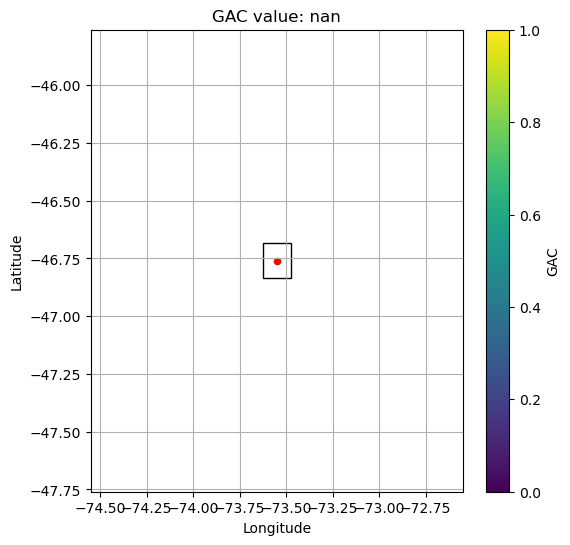

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Area centers: latitude, longitude
areas = {
    'Alaska_USA': [66.16, -153.37],
    'Auyuittuq_Canada': [67.5, -65],
    'San_Rafael_South_America': [-46.76, -73.55],
    'Jostedal_Glacier_Norway': [61.68, 7.03],
    'Karelia_Russia': [61.82, 33.24],
    'Siberia_Russia': [63.32, 115.21],
}

area = "San_Rafael_South_America"

# Select GAC
gac_area = gac[gac["region"] == area]

# Get the first value
value = gac_area.iloc[0]["data"][0]

lat, lon = areas[area]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the 0.15 x 0.15 degree footprint
square = Rectangle(
    (lon - 0.075, lat - 0.075),
    0.15,
    0.15,
    facecolor=plt.cm.viridis(value),
    edgecolor="black"
)

ax.add_patch(square)

# Add point location
ax.scatter(lon, lat, color="red", s=20)

ax.set_xlim(lon - 1, lon + 1)
ax.set_ylim(lat - 1, lat + 1)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"GAC value: {value}")

plt.colorbar(
    plt.cm.ScalarMappable(cmap="viridis"),
    ax=ax,
    label="GAC"
)

plt.grid()
plt.show()

# Calculate mean, max, min, sd, rmse

In [29]:
summary_rows = []

for df in [lac, gac]:
    for (region, satellite, datatype), group in df.groupby(
        ["region", "satellite", "datatype"]
    ):
        values = []

        for s in group["data"]:
            # s is a string like "[nan, 1.0, 2.5]"
            nums = [
                np.nan if x.strip() == "nan" else float(x)
                for x in s.strip("[]").split(",")
                if x.strip() != ""
            ]
            values.extend(nums)

        values = np.array(values, dtype=float)
        values = values[~np.isnan(values)]

        summary_rows.append({
            "region": region,
            "satellite": satellite,
            "datatype": datatype,
            "mean": np.nanmean(values) if values.size else np.nan,
            "std": values.std() if values.size else np.nan,
            "min": np.nanmin(values) if values.size else np.nan,
            "max": np.nanmax(values) if values.size else np.nan,
            "count": values.size,
        })

summary = pd.DataFrame(summary_rows)

# Organize by location
summary = summary.sort_values(
    by=["region", "satellite", "datatype"]
).reset_index(drop=True)

print(summary)

                      region satellite datatype       mean        std     min  \
0                 Alaska_USA    noaa14      gac        NaN        NaN     NaN   
1                 Alaska_USA    noaa14      lac        NaN        NaN     NaN   
2           Auyuittuq_Canada    noaa14      gac        NaN        NaN     NaN   
3           Auyuittuq_Canada    noaa14      lac        NaN        NaN     NaN   
4    Jostedal_Glacier_Norway    noaa14      gac  100.00000   0.000000  100.00   
5    Jostedal_Glacier_Norway    noaa14      lac   68.00000  19.096247   41.00   
6             Karelia_Russia    noaa14      gac  100.00000   0.000000  100.00   
7             Karelia_Russia    noaa14      lac        NaN        NaN     NaN   
8   San_Rafael_South_America    noaa14      gac    0.00000   0.000000    0.00   
9   San_Rafael_South_America    noaa14      lac   51.00000   0.000000   51.00   
10            Siberia_Russia    noaa14      gac   83.95238  16.653464   61.00   
11            Siberia_Russia

In [30]:
summary_rows = []
value_storage = {}

# Calculate statistics for LAC and GAC
for df in [lac, gac]:

    for (region, satellite, datatype), group in df.groupby(
        ["region", "satellite", "datatype"]
    ):

        values = []

        for s in group["data"]:

            # Convert string "[nan, 1.0, 2.5]" into numbers
            nums = [
                np.nan if x.strip() == "nan" else float(x)
                for x in s.strip("[]").split(",")
                if x.strip() != ""
            ]

            values.extend(nums)

        values = np.array(values, dtype=float)

        # Remove NaN values
        values = values[~np.isnan(values)]

        # Store values for RMSE calculation
        value_storage[(region, satellite, datatype)] = values

        # Add statistics
        summary_rows.append({
            "region": region,
            "satellite": satellite,
            "datatype": datatype,
            "mean": np.mean(values) if values.size else np.nan,
            "std": np.std(values) if values.size else np.nan,
            "min": np.min(values) if values.size else np.nan,
            "max": np.max(values) if values.size else np.nan,
            "count": values.size,
        })


# Create statistics dataframe
summary = pd.DataFrame(summary_rows)

summary = summary.sort_values(
    by=["region", "satellite", "datatype"]
).reset_index(drop=True)


print("Statistics:")
print(summary)


# ---------------------------------------------------
# RMSE calculation between LAC and GAC
# ---------------------------------------------------

rmse_rows = []

for region, satellite, datatype in value_storage.keys():

    if datatype == "lac":

        # Check if matching GAC exists
        if (region, satellite, "gac") in value_storage:

            lac_values = value_storage[(region, satellite, "lac")]
            gac_values = value_storage[(region, satellite, "gac")]

            # Match number of values
            n = min(len(lac_values), len(gac_values))

            if n > 0:

                rmse = root_mean_squared_error(
                    lac_values[:n],
                    gac_values[:n]
                )

            else:
                rmse = np.nan


            rmse_rows.append({
                "region": region,
                "satellite": satellite,
                "rmse": rmse,
                "count": n
            })


# Create RMSE dataframe
rmse_summary = pd.DataFrame(rmse_rows)

rmse_summary = rmse_summary.sort_values(
    by=["region", "satellite"]
).reset_index(drop=True)


print("\nRMSE:")
print(rmse_summary)

Statistics:
                      region satellite datatype       mean        std     min  \
0                 Alaska_USA    noaa14      gac        NaN        NaN     NaN   
1                 Alaska_USA    noaa14      lac        NaN        NaN     NaN   
2           Auyuittuq_Canada    noaa14      gac        NaN        NaN     NaN   
3           Auyuittuq_Canada    noaa14      lac        NaN        NaN     NaN   
4    Jostedal_Glacier_Norway    noaa14      gac  100.00000   0.000000  100.00   
5    Jostedal_Glacier_Norway    noaa14      lac   68.00000  19.096247   41.00   
6             Karelia_Russia    noaa14      gac  100.00000   0.000000  100.00   
7             Karelia_Russia    noaa14      lac        NaN        NaN     NaN   
8   San_Rafael_South_America    noaa14      gac    0.00000   0.000000    0.00   
9   San_Rafael_South_America    noaa14      lac   51.00000   0.000000   51.00   
10            Siberia_Russia    noaa14      gac   83.95238  16.653464   61.00   
11            Si

In [52]:
# ---------------------------------------------------
# RMSE calculation between LAC and GAC
# using averaged LAC values
# ---------------------------------------------------

rmse_rows = []

for region, satellite, datatype in value_storage.keys():

    if datatype == "lac":

        if (region, satellite, "gac") in value_storage:

            # Get values
            lac_values = value_storage[(region, satellite, "lac")]
            gac_values = value_storage[(region, satellite, "gac")]

            # Remove NaN values from LAC and calculate mean
            lac_values = lac_values[~np.isnan(lac_values)]
            gac_values = gac_values[~np.isnan(gac_values)]

            if len(lac_values) > 0 and len(gac_values) > 0:

                # Average all LAC values first
                lac_mean = np.mean(lac_values)

                # Compare mean LAC against every GAC value
                rmse = root_mean_squared_error(
                    gac_values,
                    np.full(len(gac_values), lac_mean)
                )

            else:
                lac_mean = np.nan
                rmse = np.nan


            rmse_rows.append({
                "region": region,
                "satellite": satellite,
                "lac_mean": lac_mean,
                "rmse": rmse,
                "count_lac": len(lac_values),
                "count_gac": len(gac_values)
            })


# Create RMSE dataframe
rmse_summary = pd.DataFrame(rmse_rows)

rmse_summary = rmse_summary.sort_values(
    by=["region", "satellite"]
).reset_index(drop=True)

print("\nRMSE:")
print(rmse_summary)


RMSE:
                     region satellite  lac_mean       rmse  count_lac  \
0                Alaska_USA    noaa14       NaN        NaN          0   
1          Auyuittuq_Canada    noaa14       NaN        NaN          0   
2   Jostedal_Glacier_Norway    noaa14     68.00  32.000000          6   
3            Karelia_Russia    noaa14       NaN        NaN          0   
4  San_Rafael_South_America    noaa14     51.00  51.000000          1   
5            Siberia_Russia    noaa14     61.25  28.155566          4   

   count_gac  
0          0  
1          0  
2          6  
3          2  
4          1  
5          3  


In [39]:
# ---------------------------------------------------
# RMSE calculation between LAC and GAC
# using mean LAC values
# ---------------------------------------------------

rmse_rows = []

for region, satellite, datatype in value_storage.keys():

    if datatype == "lac":

        if (region, satellite, "gac") in value_storage:

            lac_values = value_storage[(region, satellite, "lac")]
            gac_values = value_storage[(region, satellite, "gac")]

            # Calculate average LAC value
            lac_mean = np.mean(lac_values) if len(lac_values) > 0 else np.nan

            # Remove NaN values from GAC
            gac_values = gac_values[~np.isnan(gac_values)]

            if len(gac_values) > 0 and not np.isnan(lac_mean):

                # Compare mean LAC with each GAC value
                rmse = root_mean_squared_error(
                    gac_values,
                    np.full(len(gac_values), lac_mean)
                )

            else:
                rmse = np.nan


            rmse_rows.append({
                "region": region,
                "satellite": satellite,
                "lac_mean": lac_mean,
                "rmse": rmse,
                "count_lac": len(lac_values),
                "count_gac": len(gac_values)
            })


# Create RMSE dataframe
rmse_summary = pd.DataFrame(rmse_rows)

rmse_summary = rmse_summary.sort_values(
    by=["region", "satellite"]
).reset_index(drop=True)


print("\nRMSE:")
print(rmse_summary)


RMSE:
                     region satellite  lac_mean       rmse  count_lac  \
0                Alaska_USA    noaa14       NaN        NaN          0   
1          Auyuittuq_Canada    noaa14       NaN        NaN          0   
2   Jostedal_Glacier_Norway    noaa14     68.00  32.000000          6   
3            Karelia_Russia    noaa14       NaN        NaN          0   
4  San_Rafael_South_America    noaa14     51.00  51.000000          1   
5            Siberia_Russia    noaa14     61.25  28.155566          4   

   count_gac  
0          0  
1          0  
2          6  
3          2  
4          1  
5          3  


In [71]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import root_mean_squared_error

# ---------------------------------------------------
# Read CSV files and separate LAC / GAC
# ---------------------------------------------------

folder = Path("csv/testi")

lac_df = pd.DataFrame()
gac_df = pd.DataFrame()

for file in folder.rglob("*.csv"):
    df = pd.read_csv(file)

    lac_df = pd.concat(
        [lac_df, df[df["datatype"] == "lac"]],
        ignore_index=True
    )

    gac_df = pd.concat(
        [gac_df, df[df["datatype"] == "gac"]],
        ignore_index=True
    )


# ---------------------------------------------------
# Statistics
# ---------------------------------------------------

summary_rows = []
value_storage = {}

for data_df in [lac_df, gac_df]:

    for (region, satellite, datatype), group in data_df.groupby(
        ["region", "satellite", "datatype"]
    ):

        values = []

        for data_string in group["data"]:

            # Convert "[nan, 1.0, 2.5]" to numbers
            nums = [
                np.nan if x.strip() == "nan" else float(x)
                for x in data_string.strip("[]").split(",")
                if x.strip() != ""
            ]

            values.extend(nums)

        values = np.array(values, dtype=float)

        valid_values = values[~np.isnan(values)]

        value_storage[(region, satellite, datatype)] = valid_values

        summary_rows.append({
            "region": region,
            "satellite": satellite,
            "datatype": datatype,
            "mean": np.mean(valid_values) if len(valid_values) else np.nan,
            "std": np.std(valid_values) if len(valid_values) else np.nan,
            "min": np.min(valid_values) if len(valid_values) else np.nan,
            "max": np.max(valid_values) if len(valid_values) else np.nan,
            "count": len(valid_values)
        })


summary = pd.DataFrame(summary_rows)

print("Statistics:")
print(summary)


# ---------------------------------------------------
# RMSE calculation
# One GAC value vs all valid LAC values in same date
# ---------------------------------------------------

rmse_rows = []

for (region, satellite), lac_group in lac_df.groupby(
    ["region", "satellite"]
):

    gac_group = gac_df[
        (gac_df["region"] == region) &
        (gac_df["satellite"] == satellite)
    ]

    # keep date order
    lac_group = lac_group.sort_values("date")
    gac_group = gac_group.sort_values("date")

    daily_rmse = []

    for lac_data_string, gac_data_string in zip(
        lac_group["data"],
        gac_group["data"]
    ):

        # Convert strings to lists
        lac_data = eval(
            lac_data_string,
            {"nan": np.nan}
        )

        gac_data = eval(
            gac_data_string,
            {"nan": np.nan}
        )

        lac_data = np.array(lac_data, dtype=float)
        gac_value = np.array(gac_data, dtype=float)[0]

        # Remove invalid LAC values
        lac_data = lac_data[~np.isnan(lac_data)]

        # Calculate RMSE
        if len(lac_data) > 0 and not np.isnan(gac_value):

            rmse = root_mean_squared_error(
                np.full(len(lac_data), gac_value),
                lac_data
            )

            daily_rmse.append(rmse)


    rmse_rows.append({
        "region": region,
        "satellite": satellite,
        "rmse": np.mean(daily_rmse)
            if len(daily_rmse) > 0
            else np.nan,
        "days_used": len(daily_rmse)
    })


# ---------------------------------------------------
# RMSE dataframe
# ---------------------------------------------------

rmse_summary = pd.DataFrame(rmse_rows)

rmse_summary = rmse_summary.sort_values(
    ["region", "satellite"]
).reset_index(drop=True)


print("\nRMSE:")
print(rmse_summary)

Statistics:
                      region satellite datatype       mean        std     min  \
0                 Alaska_USA    noaa14      lac        NaN        NaN     NaN   
1           Auyuittuq_Canada    noaa14      lac        NaN        NaN     NaN   
2    Jostedal_Glacier_Norway    noaa14      lac   68.00000  19.096247   41.00   
3             Karelia_Russia    noaa14      lac        NaN        NaN     NaN   
4   San_Rafael_South_America    noaa14      lac   51.00000   0.000000   51.00   
5             Siberia_Russia    noaa14      lac   61.25000  20.329320   37.25   
6                 Alaska_USA    noaa14      gac        NaN        NaN     NaN   
7           Auyuittuq_Canada    noaa14      gac        NaN        NaN     NaN   
8    Jostedal_Glacier_Norway    noaa14      gac  100.00000   0.000000  100.00   
9             Karelia_Russia    noaa14      gac  100.00000   0.000000  100.00   
10  San_Rafael_South_America    noaa14      gac    0.00000   0.000000    0.00   
11            Si

In [72]:
# LAC values in Jostedal_Glacier_Norway
jostedal_lac = lac[lac["region"] == "Jostedal_Glacier_Norway"]

# GAC values in Jostedal_Glacier_Norway
jostedal_gac = gac[gac["region"] == "Jostedal_Glacier_Norway"]

print("LAC values:")
print(jostedal_lac["data"].to_list())

print("\nGAC values:")
print(jostedal_gac["data"].to_list())

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [33]:
lac_J = jostedal_lac["data"].to_list()
gac_J = jostedal_gac["data"].to_list()

In [34]:
lac_J

['[nan, 81.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 82.0, nan]',
 '[nan, nan, nan, nan, nan, nan, nan, 41.0, nan, nan, nan, nan, nan, nan, nan, nan]',
 '[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]',
 '[nan, 81.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 82.0, nan]',
 '[nan, nan, nan, nan, nan, nan, nan, 41.0, nan, nan, nan, nan, nan, nan, nan, nan]',
 '[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]']

In [44]:
import numpy as np

data = [
'[nan, 81.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 82.0, nan]',
'[nan, nan, nan, nan, nan, nan, nan, 41.0, nan, nan, nan, nan, nan, nan, nan, nan]',
'[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]',
'[nan, 81.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 82.0, nan]',
'[nan, nan, nan, nan, nan, nan, nan, 41.0, nan, nan, nan, nan, nan, nan, nan, nan]',
'[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]'
]

means = []

for s in data:
    values = [
        np.nan if x.strip() == "nan" else float(x)
        for x in s.strip("[]").split(",")
    ]

    values = np.array(values, dtype=float)

    means.append(np.nanmean(values) if not np.all(np.isnan(values)) else np.nan)

print(means)

[np.float64(81.5), np.float64(41.0), nan, np.float64(81.5), np.float64(41.0), nan]


In [48]:
import numpy as np

data = [np.float64(81.5), np.float64(41.0), np.nan, np.float64(81.5), np.float64(41.0), np.nan]

values1 = np.array(data, dtype=float)

print(values1)

[81.5 41.   nan 81.5 41.   nan]


In [45]:
gac_J

['[100.0]', '[100.0]', '[100.0]', '[100.0]', '[100.0]', '[100.0]']

In [49]:
import numpy as np

data = ['[100.0]', '[100.0]', '[100.0]', '[100.0]', '[100.0]', '[100.0]']

values2 = np.array([
    float(x.strip("[]"))
    for x in data
], dtype=float)

print(values2)

[100. 100. 100. 100. 100. 100.]


In [51]:
import numpy as np
from sklearn.metrics import root_mean_squared_error

# Convert to arrays
values1 = np.array(values1, dtype=float)
values2 = np.array(values2, dtype=float)

# Remove pairs containing NaN
mask = ~np.isnan(values1) & ~np.isnan(values2)

values1_clean = values1[mask]
values2_clean = values2[mask]

# Calculate RMSE
rmse = root_mean_squared_error(
    values1_clean,
    values2_clean
)

print("RMSE:", rmse)

RMSE: 43.72213398268662
